### Poređenje modela za super-rezoluciju slika

<small>

U ovoj svesci se porede rezultati prethodno istreniranih modela za super-rezoluciju slika:

- **Bicubic interpolacija** — referentna donja granica, bez treniranja
- **SRCNN** — osnovni konvolutivni model
- **SRResNet** — arhitektonski unapređen model sa rezidualnim blokovima
- **ESRGAN** — model sa adversarijalnim i perceptualnim gubitkom

Svi modeli se porede na **istim test skupovima** (Set5, Set14), koristeći **iste metrike** (PSNR, SSIM), radi fer poređenja.

<small>

#### I : Učitavanje rezultata svih modela

<small>

> **Napomena:** Vrednosti `Num_Params` su izvučene direktno iz sačuvanih `.pth` fajlova (state_dict), dok su PSNR/SSIM vrednosti rezultat evaluacije na Set5 i Set14 test skupovima korišćenjem istog protokola za sve modele.

<small>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


results = [
    {
        "Model": "Bicubic",
        "Set5_PSNR": 	26.700074,
        "Set5_SSIM": 0.789921,
        "Set14_PSNR": 24.256168, 
        "Set14_SSIM": 0.685504,
        "Num_Params": 0,     # nema trenirane parametre
    },
    {
        "Model": "SRCNN",
        "Set5_PSNR": 27.976200,
        "Set5_SSIM": 	0.824395,
        "Set14_PSNR": 25.135848, 
        "Set14_SSIM": 0.721339, 
        "Num_Params": 	20_099,  
    },
    {
        "Model": "SRResNet",
        "Set5_PSNR": 28.8503,
        "Set5_SSIM": 0.8468,
        "Set14_PSNR": 25.7176,
        "Set14_SSIM": 0.7384,
        "Num_Params": 1_549_462,
    },
    {
        "Model": "ESRGAN",
        "Set5_PSNR": 	25.883649,
        "Set5_SSIM": 0.774705,
        "Set14_PSNR": 23.812411,
        "Set14_SSIM": 0.689647,
        "Num_Params": 	5_906_627,
    },
]

results_df = pd.DataFrame(results)
results_df

,Model,Set5_PSNR,Set5_SSIM,Set14_PSNR,Set14_SSIM,Num_Params
0,Bicubic,26.700074,0.789921,24.256168,0.685504,0
1,SRCNN,27.976200,0.824395,25.135848,0.721339,20099
2,SRResNet,28.850300,0.846800,25.717600,0.738400,1549462
3,ESRGAN,25.883649,0.774705,23.812411,0.689647,5906627


#### II : Tabelarno poređenje modela

In [6]:
results_df.style.format({
    "Set5_PSNR": "{:.2f}",
    "Set5_SSIM": "{:.4f}",
    "Set14_PSNR": "{:.2f}",
    "Set14_SSIM": "{:.4f}",
    "Num_Params": "{:,.0f}",
})

,Model,Set5_PSNR,Set5_SSIM,Set14_PSNR,Set14_SSIM,Num_Params
0,Bicubic,26.70,0.7899,24.26,0.6855,0
1,SRCNN,27.98,0.8244,25.14,0.7213,"20,099"
2,SRResNet,28.85,0.8468,25.72,0.7384,"1,549,462"
3,ESRGAN,25.88,0.7747,23.81,0.6896,"5,906,627"


<small>

> Vidimo da najbolji PSNR i SSIM na Set5 i Set14 test skupovima ima **SRResNet**, što ga čini ubedljivo najboljim modelom po ovim kriterijumima. Iza njega se nalazi SRCNN, a ESRGAN, iako najnapredniji, maltene konzistentno pokazuje lošije rezultate čak i od bikubične interpolacije.

</small>

#### III : Grafičko poređenje modela

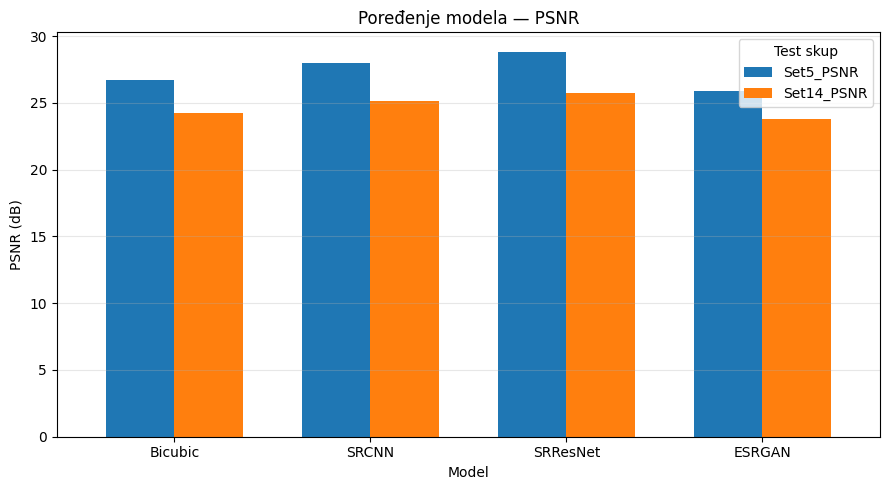

In [7]:
plot_df = results_df.set_index("Model")[["Set5_PSNR", "Set14_PSNR"]]

plot_df.plot(kind="bar", figsize=(9, 5), width=0.7)
plt.title("Poređenje modela — PSNR")
plt.xlabel("Model")
plt.ylabel("PSNR (dB)")
plt.xticks(rotation=0)
plt.legend(title="Test skup")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

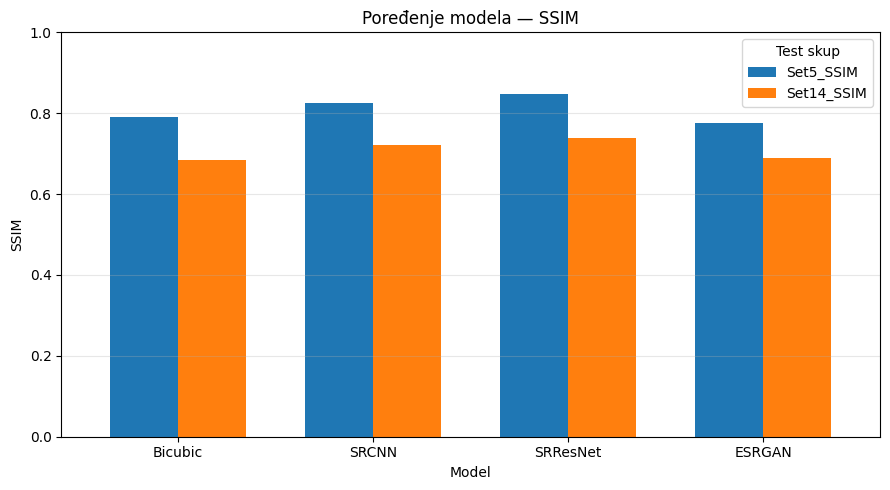

In [8]:
plot_df = results_df.set_index("Model")[["Set5_SSIM", "Set14_SSIM"]]

plot_df.plot(kind="bar", figsize=(9, 5), width=0.7)
plt.title("Poređenje modela — SSIM")
plt.xlabel("Model")
plt.ylabel("SSIM")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Test skup")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

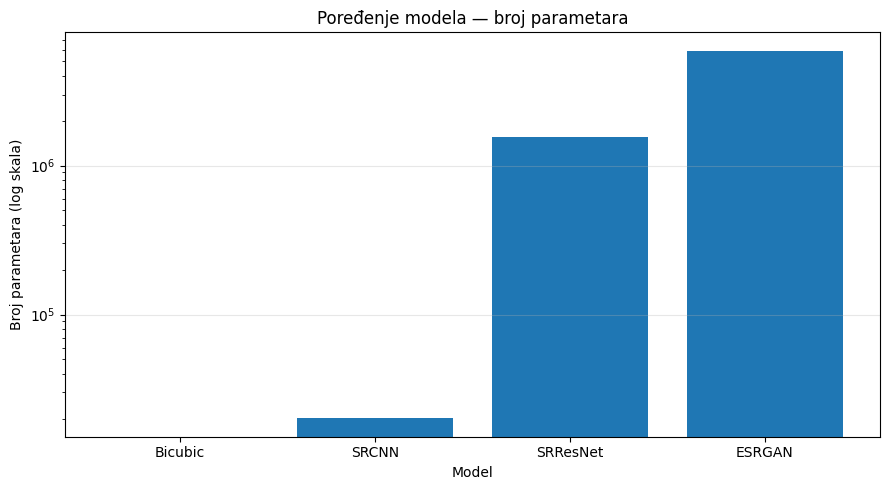

In [9]:
plt.figure(figsize=(9, 5))
plt.bar(results_df["Model"], results_df["Num_Params"])
plt.yscale("log")
plt.title("Poređenje modela — broj parametara")
plt.xlabel("Model")
plt.ylabel("Broj parametara (log skala)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

#### IV : Vizuelno poređenje rekonstrukcija

Radi vizuelnog utiska, prikazano je 5 primera iz Set5 skupa (`image_SRF_4`). LR slike su preuzete direktno iz gotovog Set5 paketa (a ne generisane bikubičnim smanjenjem HR slike), radi doslednosti sa standardnim benchmark protokolom.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# ------------------------------------------------------------------
# Definicije arhitektura (kopirano iz 03_SRCNN, 04_SRResNet, 05_ESRGAN)
# ------------------------------------------------------------------

class SRCNN(nn.Module):
    def __init__(self):
        super(SRCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=9, padding=4)
        self.conv2 = nn.Conv2d(64, 32, kernel_size=1, padding=0)
        self.conv3 = nn.Conv2d(32, 3, kernel_size=5, padding=2)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = self.conv3(x)
        return x


class ResidualBlock(nn.Module):
    def __init__(self, channels=64):
        super(ResidualBlock, self).__init__()
        self.conv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(channels)
        self.prelu = nn.PReLU()
        self.conv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(channels)

    def forward(self, x):
        residual = x
        out = self.prelu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return out + residual


class SRResNet(nn.Module):
    def __init__(self, num_channels=3, num_res_blocks=16, scale_factor=4):
        super(SRResNet, self).__init__()
        self.entry = nn.Sequential(
            nn.Conv2d(num_channels, 64, kernel_size=9, padding=4),
            nn.PReLU()
        )
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(64) for _ in range(num_res_blocks)]
        )
        self.mid_conv = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64)
        )
        upsample_blocks = []
        for _ in range(int(np.log2(scale_factor))):
            upsample_blocks += [
                nn.Conv2d(64, 256, kernel_size=3, padding=1),
                nn.PixelShuffle(2),
                nn.PReLU()
            ]
        self.upsample = nn.Sequential(*upsample_blocks)
        self.exit = nn.Conv2d(64, num_channels, kernel_size=9, padding=4)

    def forward(self, x):
        out1 = self.entry(x)
        out = self.res_blocks(out1)
        out = self.mid_conv(out)
        out = out + out1
        out = self.upsample(out)
        out = self.exit(out)
        return out


class RDB(nn.Module):
    def __init__(self, channels=64, growth_channels=32):
        super(RDB, self).__init__()
        self.conv1 = nn.Conv2d(channels, growth_channels, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(channels + growth_channels, growth_channels, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(channels + 2*growth_channels, growth_channels, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(channels + 3*growth_channels, growth_channels, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(channels + 4*growth_channels, channels, kernel_size=3, padding=1)

    def forward(self, x):
        x1 = F.leaky_relu(self.conv1(x), negative_slope=0.2, inplace=True)
        x2 = F.leaky_relu(self.conv2(torch.cat([x, x1], dim=1)), negative_slope=0.2, inplace=True)
        x3 = F.leaky_relu(self.conv3(torch.cat([x, x1, x2], dim=1)), negative_slope=0.2, inplace=True)
        x4 = F.leaky_relu(self.conv4(torch.cat([x, x1, x2, x3], dim=1)), negative_slope=0.2, inplace=True)
        x5 = self.conv5(torch.cat([x, x1, x2, x3, x4], dim=1))
        return x + 0.2 * x5


class RRDB(nn.Module):
    def __init__(self, channels=64, growth_channels=32):
        super(RRDB, self).__init__()
        self.rdb1 = RDB(channels=channels, growth_channels=growth_channels)
        self.rdb2 = RDB(channels=channels, growth_channels=growth_channels)
        self.rdb3 = RDB(channels=channels, growth_channels=growth_channels)

    def forward(self, x):
        out = self.rdb1(x)
        out = self.rdb2(out)
        out = self.rdb3(out)
        return x + 0.2 * out


class Generator(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, channels=64, num_rrdb=8):
        super(Generator, self).__init__()
        self.conv_first = nn.Conv2d(in_channels, channels, kernel_size=3, padding=1)
        self.rrdb_blocks = nn.Sequential(*[RRDB(channels=channels) for _ in range(num_rrdb)])
        self.trunk_conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.upconv1 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.upconv2 = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.hr_conv = nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        self.conv_last = nn.Conv2d(channels, out_channels, kernel_size=3, padding=1)

    def forward(self, x):
        first_features = self.conv_first(x)
        trunk = self.rrdb_blocks(first_features)
        trunk = self.trunk_conv(trunk)
        x = first_features + trunk
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = self.upconv1(x)
        x = F.leaky_relu(x, negative_slope=0.2, inplace=True)
        x = F.interpolate(x, scale_factor=2, mode="nearest")
        x = self.upconv2(x)
        x = F.leaky_relu(x, negative_slope=0.2, inplace=True)
        x = self.hr_conv(x)
        x = F.leaky_relu(x, negative_slope=0.2, inplace=True)
        x = self.conv_last(x)
        return x


# ------------------------------------------------------------------
# Učitavanje istreniranih težina
# ------------------------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

srcnn_model = SRCNN().to(device)
srcnn_model.load_state_dict(torch.load("/Users/stasatonic/Rekonstrukcija-i-super-rezolucija-istorijskih-slika/models/srcnn_best.pth", map_location=device))
srcnn_model.eval()

srresnet_model = SRResNet().to(device)
srresnet_model.load_state_dict(torch.load("/Users/stasatonic/Rekonstrukcija-i-super-rezolucija-istorijskih-slika/models/srresnet_best.pth", map_location=device))
srresnet_model.eval()

esrgan_model = Generator().to(device)
esrgan_model.load_state_dict(torch.load("/Users/stasatonic/Rekonstrukcija-i-super-rezolucija-istorijskih-slika/models/esrgan_best.pth", map_location=device))
esrgan_model.eval()

print("Svi modeli uspešno učitani.")

Svi modeli uspešno učitani.


[W NNPACK.cpp:64] Could not initialize NNPACK! Reason: Unsupported hardware.


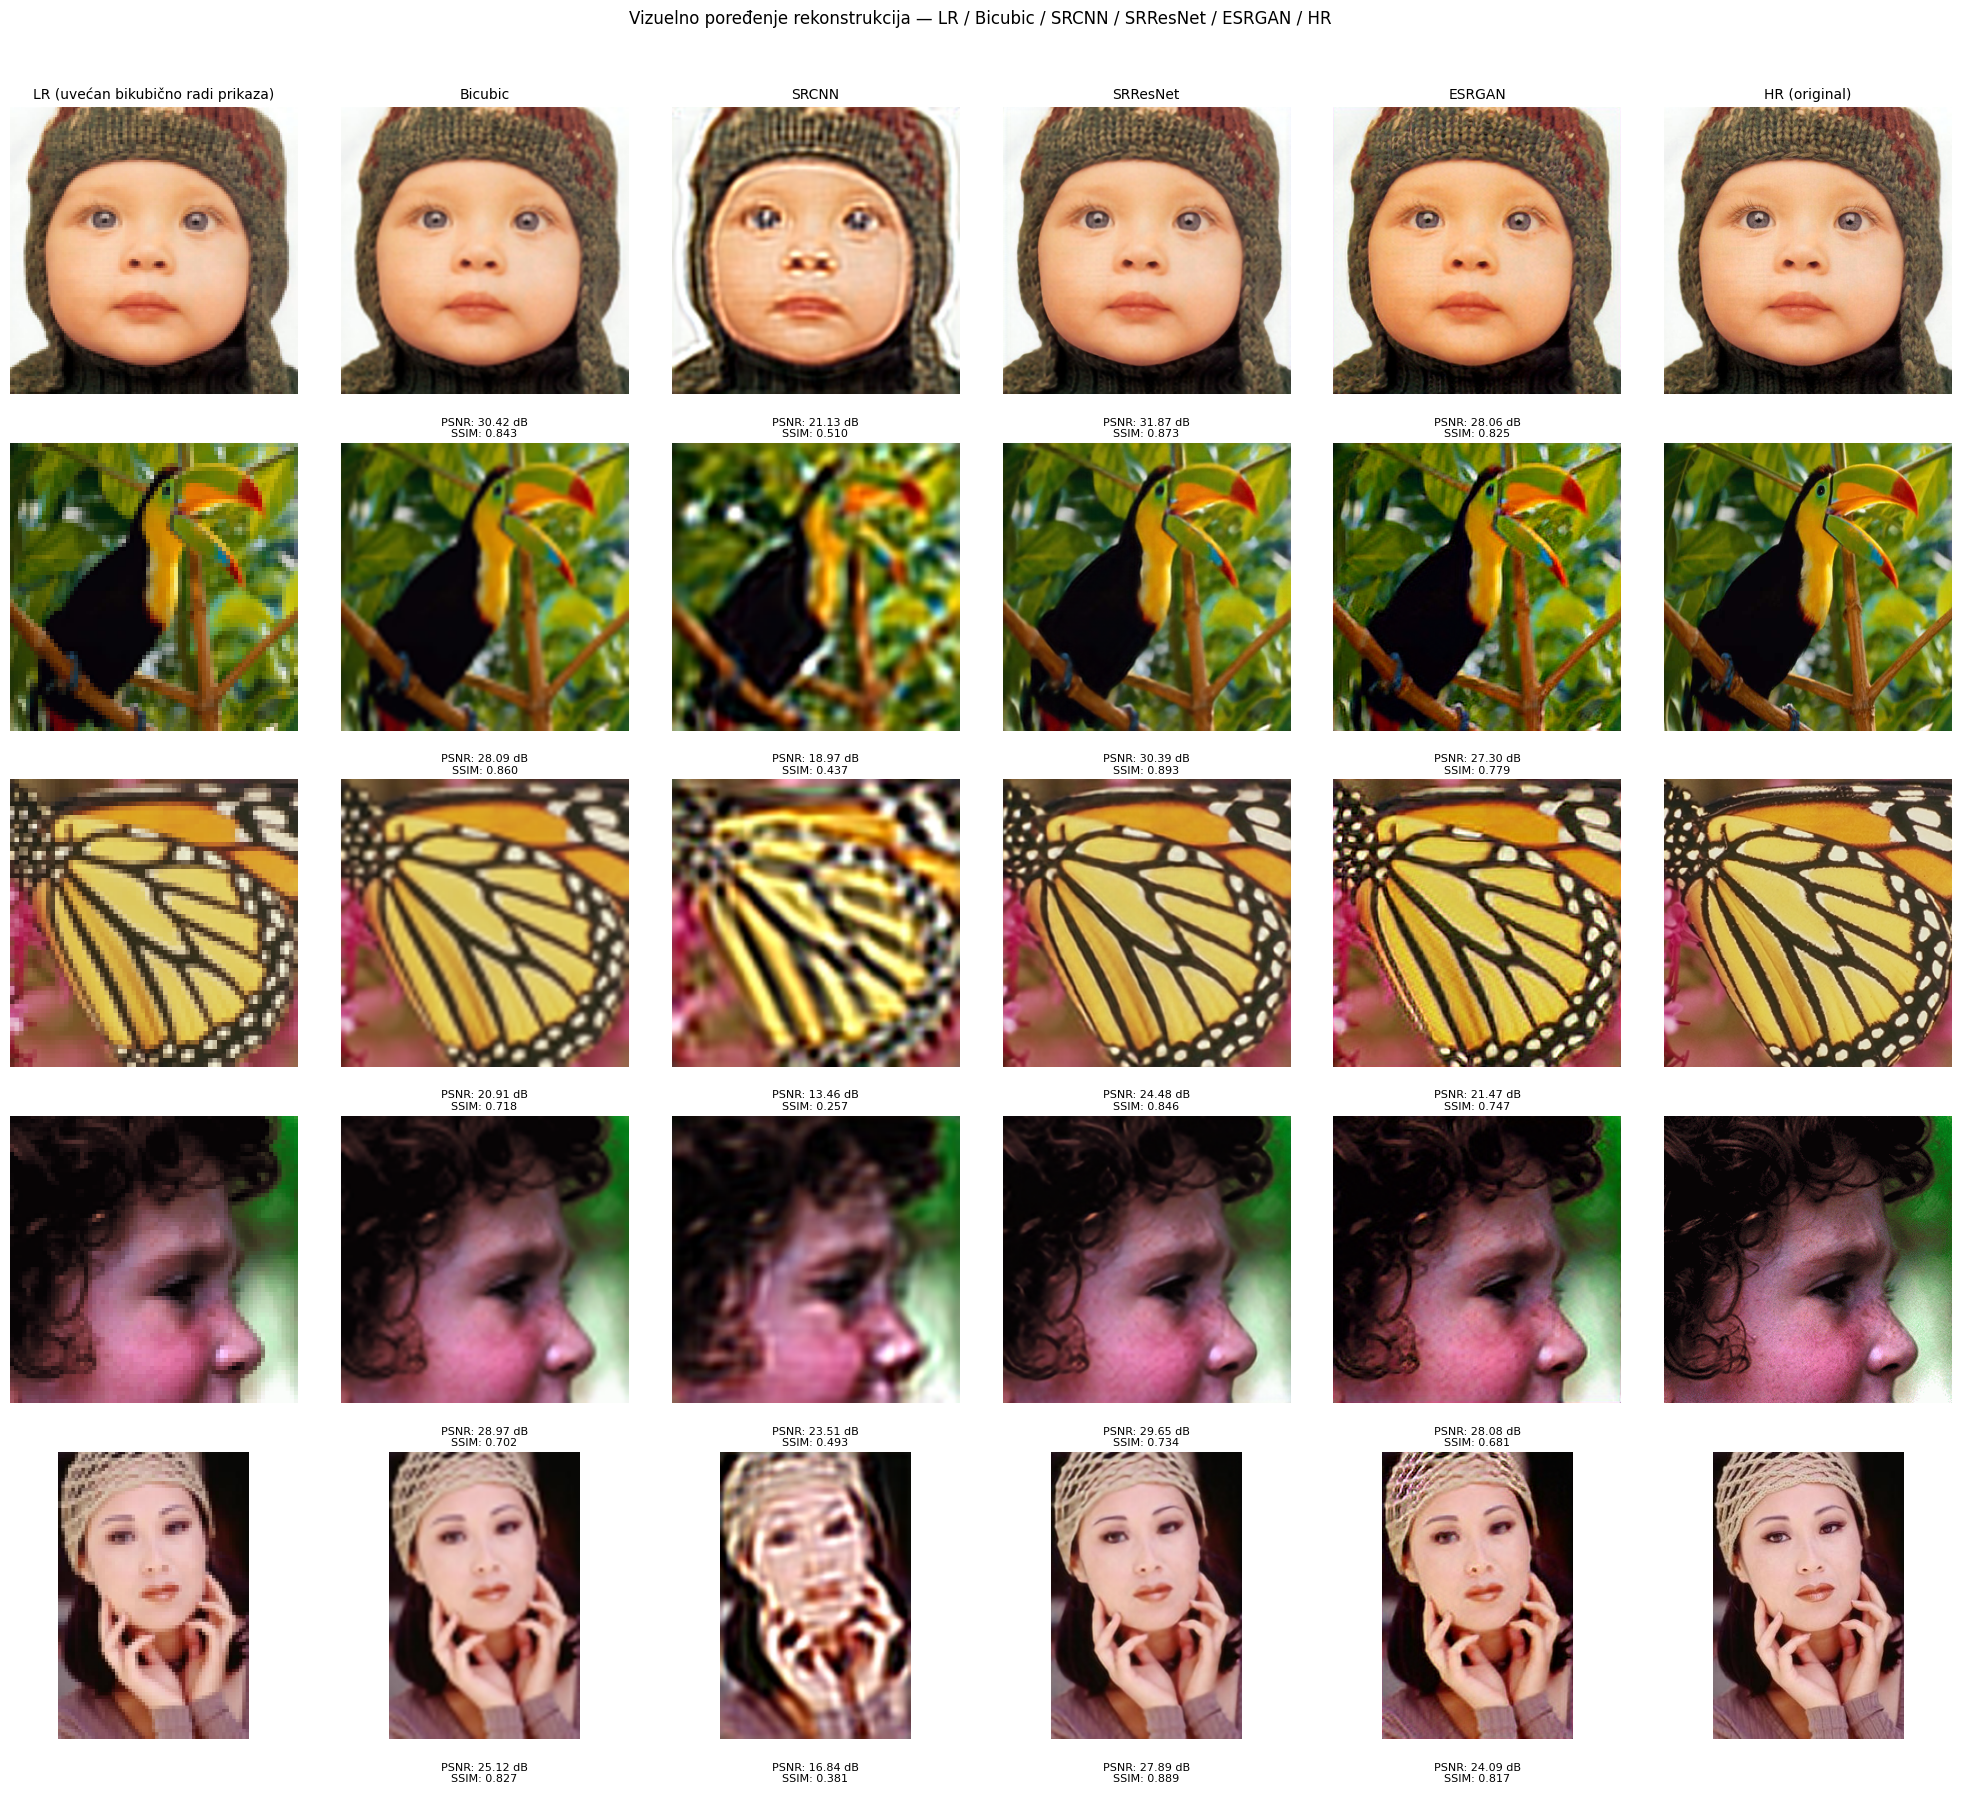

In [20]:
import os
import torch
import numpy as np
from PIL import Image
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity as ssim_metric
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# 1) Pomoćne funkcije
# ------------------------------------------------------------------
def load_hr_lr_pair(hr_dir, lr_dir, fname):
    hr = Image.open(os.path.join(hr_dir, fname)).convert("RGB")
    lr = Image.open(os.path.join(lr_dir, fname)).convert("RGB")
    return hr, lr

def bicubic_upscale(lr_img, size):
    return lr_img.resize(size, Image.BICUBIC)

def model_upscale(model, lr_img, out_size):
    lr_tensor = torch.from_numpy(np.array(lr_img)).permute(2, 0, 1).float() / 255.0
    lr_tensor = lr_tensor.unsqueeze(0).to(device)
    with torch.no_grad():
        sr_tensor = model(lr_tensor).clamp(0, 1)
    sr_img = sr_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    sr_img = (sr_img * 255).astype(np.uint8)
    sr_pil = Image.fromarray(sr_img)
    if sr_pil.size != out_size:
        sr_pil = sr_pil.resize(out_size, Image.BICUBIC)
    return sr_pil

def compute_metrics(sr_img, hr_img):
    sr_arr = np.array(sr_img)
    hr_arr = np.array(hr_img)
    p = psnr_metric(hr_arr, sr_arr, data_range=255)
    s = ssim_metric(hr_arr, sr_arr, channel_axis=2, data_range=255)
    return p, s

# ------------------------------------------------------------------
# 2) Izbor test slika (par primera iz Set5, scale=4)
# ------------------------------------------------------------------
hr_dir = os.path.join(set5_dir, "image_SRF_4", "HR")
lr_dir = os.path.join(set5_dir, "image_SRF_4", "LR")

example_files = sorted([
    f for f in os.listdir(hr_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp"))
])[:5]

num_examples = len(example_files)
fig, axes = plt.subplots(num_examples, 6, figsize=(20, 3.5 * num_examples))

col_titles = ["LR (uvećan bikubično radi prikaza)", "Bicubic", "SRCNN", "SRResNet", "ESRGAN", "HR (original)"]

for row, fname in enumerate(example_files):
    hr_img, lr_img = load_hr_lr_pair(hr_dir, lr_dir, fname)
    out_size = hr_img.size

    bicubic_img = bicubic_upscale(lr_img, out_size)
    srcnn_img = model_upscale(srcnn_model, lr_img, out_size)
    srresnet_img = model_upscale(srresnet_model, lr_img, out_size)
    esrgan_img = model_upscale(esrgan_model, lr_img, out_size)

    lr_display = lr_img.resize(out_size, Image.NEAREST)  # samo radi prikaza, ne za metrike

    images = [lr_display, bicubic_img, srcnn_img, srresnet_img, esrgan_img, hr_img]

    for col, (img, title) in enumerate(zip(images, col_titles)):
        ax = axes[row, col]
        ax.imshow(img)
        ax.axis("off")
        if row == 0:
            ax.set_title(title, fontsize=10)

        if col in (1, 2, 3, 4):
            p, s = compute_metrics(img, hr_img)
            ax.text(0.5, -0.08, f"PSNR: {p:.2f} dB\nSSIM: {s:.3f}",
                     transform=ax.transAxes, ha="center", va="top", fontsize=8)

    axes[row, 0].set_ylabel(fname, fontsize=9)

plt.suptitle("Vizuelno poređenje rekonstrukcija — LR / Bicubic / SRCNN / SRResNet / ESRGAN / HR", y=1.02)
plt.tight_layout()
plt.show()

#### V : Zaključak

<small>

Na oba test skupa (Set5, Set14), rangiranje po PSNR/SSIM je: **SRResNet > SRCNN > Bicubic > ESRGAN**.

- **SRCNN** donosi očekivano poboljšanje u odnosu na bikubičnu interpolaciju (~+1.3 dB PSNR na Set5), uz svega ~20K parametara — potvrđuje da i jednostavna konvolutivna arhitektura uči korisnu transformaciju.
- **SRResNet** postiže najbolji rezultat po PSNR/SSIM metrikama na oba skupa, zahvaljujući rezidualnim blokovima i dubljoj arhitekturi (~1.5M parametara).
- **ESRGAN**, iako ima najviše parametara (~5.9M), postiže *niži* PSNR/SSIM čak i od bikubične interpolacije. Ovo nije greška, već tzv. *perception-distortion tradeoff*: adversarijalni i perceptualni gubitak (VGG feature loss) eksplicitno guraju generator da proizvodi realističnije, oštrije teksture po cenu piksel-po-piksel podudaranja sa HR slikom, na čemu se PSNR/SSIM zasnivaju. Model "izmišlja" verodostojne detalje umesto da ih verno rekonstruiše.
- Trend se poklapa sa arhitektonskim očekivanjima (SRCNN < SRResNet po dubini/rezidualnim vezama), ali odstupa od naivnog očekivanja da je ESRGAN "najbolji" jer ESRGAN cilja drugačiji kriterijum kvaliteta (percepcija), ne isti koji mere PSNR/SSIM.
- Vizuelno poređenje (Sekcija IV) treba tumačiti uz ovaj nalaz: iako ESRGAN ima niže brojčane metrike, često se subjektivno doživljava kao oštriji/realističniji, što je upravo poenta perceptualnog gubitka i ključna razlika u odnosu na SRResNet (koji nema batch normalizaciju u generatoru, što je arhitektonska razlika vredna pomena).
- **Trade-off broj parametara / kvalitet**: SRResNet nudi najbolji odnos rezultata i računske cene; ESRGAN je skuplji i po PSNR/SSIM "lošiji", ali rešava drugačiji problem.

<small>